In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM
from functools import partial
jax.devices()

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


[CudaDevice(id=0), CudaDevice(id=1)]

In [2]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [3]:
import numpy as np
import scipy.ndimage as ndi

def img_aug(x):
    xs_batch = x["image"]

    # Accept (B,H,W,1) by squeezing the channel
    if xs_batch.ndim == 4 and xs_batch.shape[-1] == 1:
        xs_batch = xs_batch[..., 0]

    # --- small rotation for the whole batch ---
    angle = np.random.uniform(-4.0, 4.0)  # degrees
    xs_batch = ndi.rotate(
        xs_batch,
        angle=angle,
        axes=(1, 2),
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0
    )

    # --- small translation for the whole batch ---
    ty = np.random.uniform(-2.0, 2.0)     # shift in y (pixels)
    tx = np.random.uniform(-2.0, 2.0)     # shift in x (pixels)
    # For a (B,H,W) array, give one shift per axis: (B, H, W) -> (0, ty, tx)
    xs_batch = ndi.shift(
        xs_batch,
        shift=(0.0, ty, tx),
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False  # only needed for order > 1
    )

    # --- normalize to [0,1] ---
    xs_batch = xs_batch.astype(np.float32)
    if xs_batch.max() > 1.0:
        xs_batch /= 255.0

    # dequantization noise
    xs_batch += np.random.uniform(0.0, 1/255.0, xs_batch.shape).astype(np.float32)

    # --- map to [-1,1] and clamp ---
    xs_batch = 2.0 * xs_batch - 1.0
    xs_batch = np.clip(xs_batch, -1.0, 1.0)

    # add channels-last dim back
    return xs_batch[..., None].astype(np.float32)


In [4]:
from probjax.nn.io_util import chunkify, unchunkify

In [5]:
mu0, std0 = 0,0
for _ in range(10):
    data = img_aug(dataset['train'][:])
    data = np.arctanh(data * 0.9999)  # Inverse tanh transform to unconstrained space
    mu0 += np.mean(data, axis=0)
    std0 += np.std(data, axis=0)
mu0 /= 10
std0 = np.clip(std0 / 10, 1e-4, None)

def normalize(x):
    xs_unconstrained = jnp.arctanh(x*0.9999)
    return (xs_unconstrained - mu0) / std0
def denormalize(x):
    xs_unconstrained = x * std0 + mu0
    return jnp.tanh(xs_unconstrained)


In [6]:

def to_seq(x):
    x = jax.vmap(partial(jax.image.resize,shape=(30,30,1), method='bilinear'))(x)
    return jax.vmap(partial(chunkify, chunk_shape=(3,3)))(x)

def to_img(x):
    x = jax.vmap(partial(unchunkify, chunk_shape=(3,3), spatial_shape=(30,30)))(x)
    return jax.vmap(partial(jax.image.resize, shape=(28,28,1), method='bilinear'))(x)

In [7]:
from probjax.nn.io_util import DataLoader
n_devices = jax.local_device_count()
loader = DataLoader(dataset["train"],batch_size=512*n_devices, num_prefetch_host=8, num_prefetch_device=2, shard=True, host_transforms=[img_aug, normalize], num_async_workers=1)

In [8]:
datastream = iter(loader)

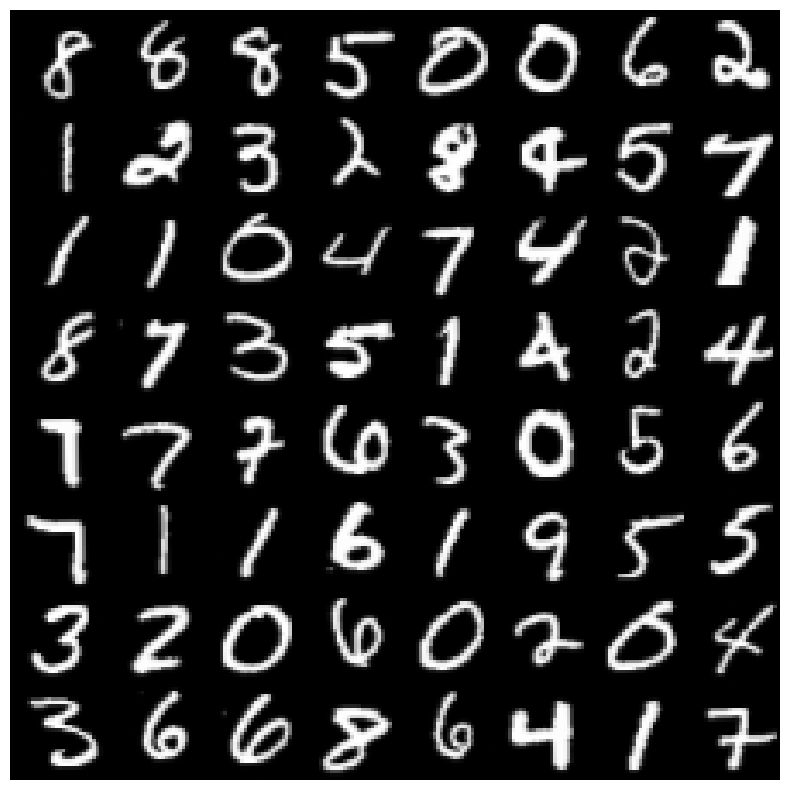

In [9]:
images = denormalize((next(datastream)))[0,:64,:,:,0]
stacked_images = np.vstack([np.hstack(images[i*8:(i+1)*8]) for i in range(8)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [10]:
from probjax.nn import Transformer, ResizeConv, SpatialSelfAttention, PosEncode, GatedFuse, RotaryPosEncode, LearnablePosEncode
from probjax.nn.layers.attention import MultiHeadAttention, flex_attention
from functools import partial
import time

In [11]:

class Denoiser(nnx.Module):
    def __init__(self, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,256, rngs=rngs, learnable=True)
        #self.pos_encode = RotaryPosEncode(256,rngs=rngs)
        #self.pos_encode = PosEncode(rngs=rngs)
        self.pos_encode = LearnablePosEncode(512, max_seq_len=(28*28//2)+1, rngs=rngs)
        self.enc = nnx.Linear(9, 512, rngs=rngs)
        self.dec = nnx.Linear(512, 9, rngs=rngs, kernel_init=nnx.initializers.zeros)
        self.net = Transformer(
            512,
            8,
            10,
            32,
            context_dim=256,
            attention_fn=flex_attention,
            #drop_path_rate=[0.1*i/11 for i in range(12)],
            normalize_qk_attn=True,
            rngs=rngs,
            dtype=jnp.bfloat16,
            precision="BF16_BF16_F32",
            preferred_element_type=jnp.float32,
            attn_fuse_cls=GatedFuse,
        )

    def __call__(self, t, x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        tokens = to_seq(x)
        tokens = self.enc(tokens)
        tokens = self.pos_encode(tokens)
        tokens = self.net(tokens, context=time_embed)
        out = self.dec(tokens)
        out = to_img(out)
        return out

net = Denoiser(nnx.Rngs(0))
model = EDM(net,loss_type="v")
graphdef, params, state = nnx.split(model, nnx.Param, ...)

In [12]:
from flax.jax_utils import replicate as flax_replicate, unreplicate as flax_unreplicate

def replicate(x):
    return flax_replicate(x)

def unreplicate(x):
    return flax_unreplicate(x)

def split_rng(rng):
    if getattr(rng, 'ndim', 0) > 1:
        return rng
    return jax.random.split(rng, jax.local_device_count())


In [13]:
nnx.display(model)

In [14]:
model.train()

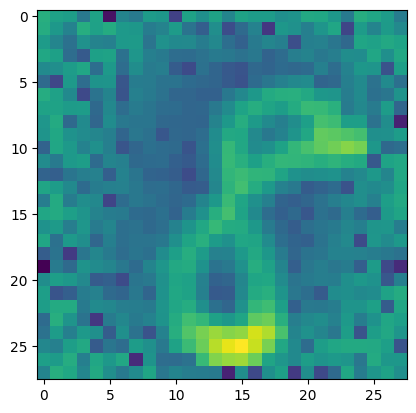

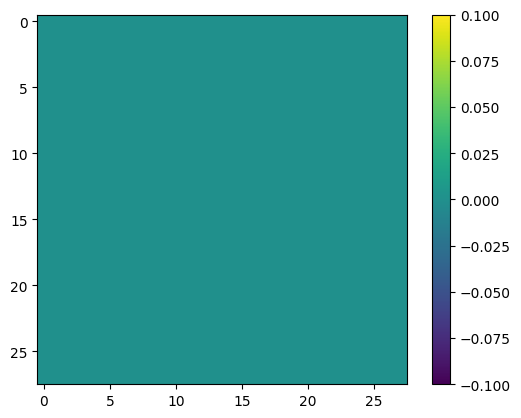

In [15]:
x = next(datastream)
plt.imshow(x[0,0])
plt.show()
plt.imshow(model(jnp.ones((512,1,1,1))*0.5,x[0],verbose=True)[0])
plt.colorbar()

In [16]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_util.tree_leaves(params)))

Number of parameters:  56682761


In [17]:
model.std0.value

1.0

In [18]:


def loss_fn(params, state, x, rng):
    model = nnx.merge(graphdef, params, state, copy=True)
    model.train()

    l = model.loss(rng, x, axis=(-3,-2,-1), adaptive_weight_p=0.8, adaptive_weight_eps=1e-3)
    _, _, state = nnx.split(model, nnx.Param, ...)
    return l, state


In [19]:
from functools import partial
import optax

axis_name = "devices"

scheduler = optax.cosine_onecycle_schedule(200*500, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(5.), optax.radam(scheduler))
opt_state = opt.init(params)
ema = optax.ema(0.999)
ema_state = ema.init(params)

params = replicate(params)
state = replicate(state)
opt_state = replicate(opt_state)
ema_state = replicate(ema_state)

@partial(jax.pmap, axis_name=axis_name)
def update(params, state, opt_state, ema_state, x, rng):
    (loss, state), grads = jax.value_and_grad(loss_fn, has_aux=True)(params, state, x, rng)
    loss = jnp.mean(loss)
    loss = jax.lax.pmean(loss, axis_name)
    grads = jax.lax.pmean(grads, axis_name)
    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    _, ema_state = ema.update(params, ema_state)
    return params, state, opt_state, ema_state, loss

def train_step(params, state, opt_state, ema_state, xs, rng):
    rng = split_rng(rng)
    params, state, opt_state, ema_state, loss = update(params, state, opt_state, ema_state, xs, rng)
    return params, state, opt_state, ema_state, jax.device_get(loss)[0]


In [20]:
key = jax.random.key(2)

In [21]:
from probjax.utils.bmutil import benchmark

In [22]:
with benchmark() as bm:
    x = next(datastream)
    for _ in bm:
        _ = train_step(params, state, opt_state, ema_state, x, key)


GPU Utilization: 1% +/- 10%,GPU Memory Utilization: 0% +/- 4% 
CPU Utilization: 3% +/- 2%
Memory Utilization: 0% +/- 0%
Benchmark collected no steady-state iterations; ensure the block runs at least twice.


In [35]:
# Example training iteration
for i in range(100):
    losses = []
    key, key_loss = jax.random.split(key, 2)
    key_loss = jax.random.split(key_loss, 500)
    for j in range(500):
        xs = next(datastream)
        params, state, opt_state, ema_state, loss = train_step(params, state, opt_state, ema_state, xs, key_loss[j])
        losses.append(loss)
    print(sum(losses) / len(losses))

3.4154058
3.416112
3.414883
3.416104
3.4169927
3.4155498
3.413136
3.4145417
3.4132917
3.4120045
3.4127793
3.4121318
3.4116104
3.4126644
3.4104364
3.4122524
3.4104557
3.409484


KeyboardInterrupt: 

In [ ]:
ema_params, _ = ema.update(unreplicate(params), unreplicate(ema_state))

: 

In [ ]:
# convert device arrays to host numpy arrays and save
import pickle
checkpoint = {
	"params": jax.device_get(params),
	"state": jax.device_get(state),
	"opt_state": jax.device_get(opt_state),
	"ema_state": jax.device_get(ema_state),
}

with open("checkpoint.pkl", "wb") as f:
	pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved checkpoint to checkpoint.pkl")


In [34]:
with open("checkpoint.pkl", "rb") as f:
    checkpoint = pickle.load(f)

params = checkpoint["params"]
state = checkpoint["state"]
opt_state = checkpoint["opt_state"]
ema_state = checkpoint["ema_state"]

In [ ]:
model = nnx.merge(graphdef, ema_params, unreplicate(state), copy=True)
model.eval()

In [ ]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (1,28,28,1,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(256)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x)
        return (f -0.5*g**2*score).reshape(x.shape)

    out = odeint(drift, eps,ts, method="heun")[-1]
    return denormalize(out)


In [ ]:
keys = jax.random.split(jax.random.key(0), (64,))

In [ ]:
xs = jax.vmap(sample)(keys)

In [ ]:
xs.min(),xs.max()

(Array(-1., dtype=float32), Array(1., dtype=float32))

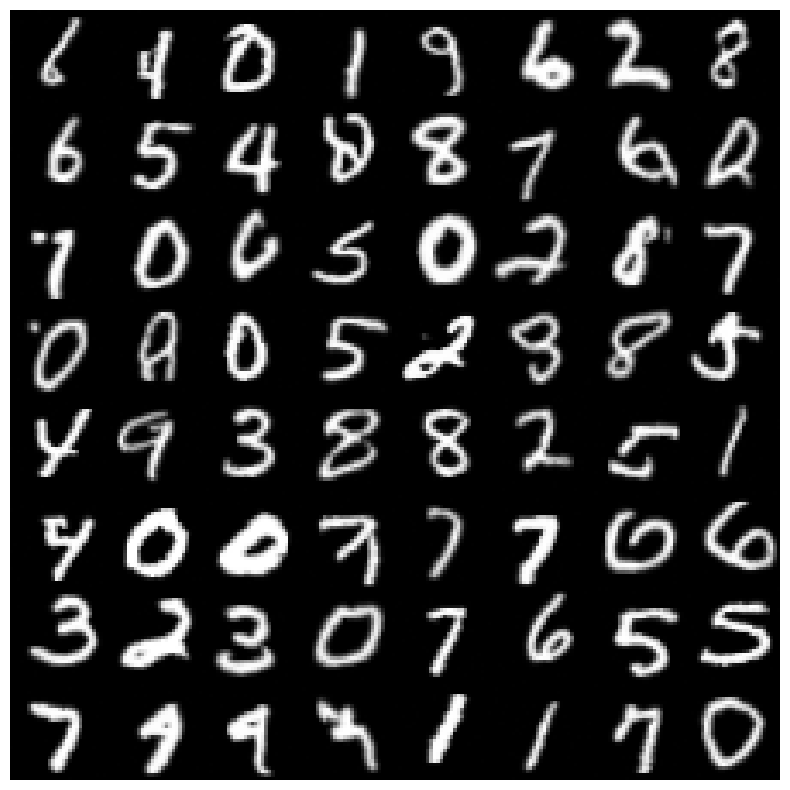

In [ ]:
import matplotlib.pyplot as plt


img = xs.reshape(8, 8, 28, 28).transpose(0, 2, 1, 3).reshape(8*28, 8*28)
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
plt.axis('off')
plt.show()